In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import levy_stable
import powerlaw
import math

def pl_fit(data):
    """
    Calculate exponent of powerlaw and standard deviation of parameter uncertainty for alpha
    """
    result = powerlaw.Fit(data).power_law
    alpha = result.alpha
    sigma = result.sigma

    return alpha, sigma

def crit_params(data):
    """
    Fit data to Levy stable distribution and output alpha and beta estimates.
    Alpha is the stability parameter and beta is the skewness parameter.
    """

    alpha_est, beta_est, loc_est, scale_est = levy_stable.fit(data)
    return alpha_est, beta_est

## Choose equity index to be analysed

In [11]:
sourcefile = 'Data/S&P500/SP500_2016-2024_daily.csv'
index_name = 'S&P500'
crisisdate = '2020-02-20' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters

In [9]:
sourcefile = 'Data/NIKKEI/Nikkei225_2010-2024 daily.csv'
index_name = 'NIKKEI'
crisisdate = '2024-08-05' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters

## Clean data

In [12]:
df_initial = pd.read_csv(sourcefile)
dates = pd.to_datetime(df_initial['Date'], format='mixed')
df_initial['Date'] = dates.dt.strftime('%Y-%m-%d')
if index_name=='S&P500': 
    pricecolname = 'Close/Last'
else: pricecolname = 'Price'
df = df_initial.sort_values(by='Date') # Sort from earliest date to latest date
df = df.reset_index(drop=True)
df = df[['Date', pricecolname]]
print(df.head())

         Date  Close/Last
0  2016-01-04    201.0192
1  2016-01-05    201.3600
2  2016-01-06    198.8200
3  2016-01-07    194.0500
4  2016-01-08    191.9230


## Estimation of Levy stable parameters

### 1 day before crisis

In [46]:
crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
windowrowend = crisisrow - 1 # Row in df corresponding to end of window, ie. 1 day before the crisis
windowrowstart = crisisrow - 1 - window # Row in df corresponding to start of window
windowprices = np.array(df[pricecolname].iloc[windowrowstart:windowrowend])
filteredreturns = []
returns = []

# Find the 'return' r
for j, price in enumerate(windowprices):
    if j < len(windowprices)-1:
        r = math.log(windowprices[j+1]) - math.log(price)

        returns.append(r)

print(f'no. of {index_name} returns = {len(returns)}')
print(f'time period of window: {df['Date'].iloc[windowrowstart]} to {df['Date'].iloc[windowrowend]}')
print(f'alpha, beta = {crit_params(returns)}')

no. of NIKKEI returns = 499
time period of window: 2022-07-21 to 2024-08-02
alpha, beta = (np.float64(1.9999942971752844), np.float64(-0.1293695913799887))


### On different days before crisis

Calculation of returns for days_bef_crisis=30 done.
days_bef_crisis=30, alpha=1.6012905148472303, beta=-0.43700641543275487
Calculation of returns for days_bef_crisis=1 done.
days_bef_crisis=1, alpha=1.6134684257560916, beta=-0.4293631004970137


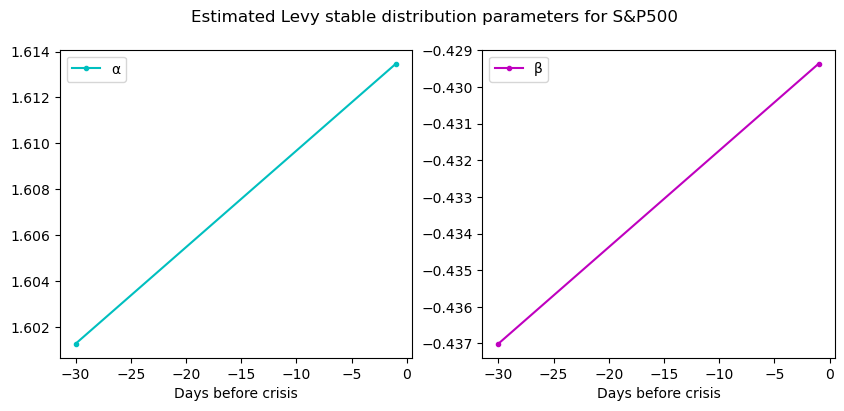

In [13]:
days_grid = [30, 1] # No. of market days before crisis

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
neg_days_grid = neg_days_grid = [-day for day in days_grid] # Get negative days
alphas = []
betas = []

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

for days_bef_crisis in days_grid:
    windowrowend = crisisrow - days_bef_crisis
    windowrowstart = crisisrow - days_bef_crisis - window
    windowprices = np.array(df[pricecolname].iloc[windowrowstart:windowrowend])

    returns = []

    # Find the return, r
    for j, price in enumerate(windowprices):
        if j < len(windowprices)-1:
            r = math.log(windowprices[j+1]) - math.log(price)

            returns.append(r)

    print(f'Calculation of returns for days_bef_crisis={days_bef_crisis} done.')
    alpha, beta = crit_params(returns)
    print(f'days_bef_crisis={days_bef_crisis}, alpha={alpha}, beta={beta}')
    alphas.append(alpha)
    betas.append(beta)
ax1.plot(neg_days_grid, alphas, color='c', marker='.', label='α')
ax2.plot(neg_days_grid, betas, color = 'm', marker='.', label='β')
fig.suptitle(f'Estimated Levy stable distribution parameters for {index_name}')
ax1.set_xlabel('Days before crisis')
ax2.set_xlabel('Days before crisis')
ax1.legend()
ax2.legend()
plt.show()